In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
from matplotlib.ticker import ScalarFormatter, FuncFormatter
import math
from scipy.stats.mstats import gmean
from scipy.stats import gamma, poisson, linregress, beta, norm
from scipy import optimize
from scipy import interpolate
import time
import random
import pickle as pkl
from cratersfd import *
%matplotlib inline

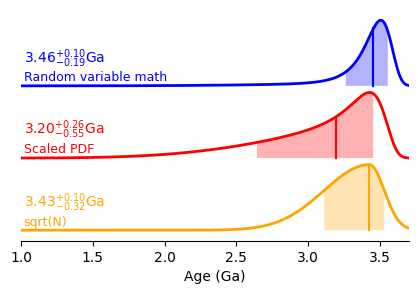

In [16]:
N = 10
area = 2500
dmin = 1

fig = plt.figure(figsize=(5, 3))
ax = fig.add_subplot(111)

(lambda_pdf(N) / area).apply(ncf_inv).plot(
    kind='median', label=True, 
    pdf_label='Random variable math',
    xlim=[1, 4], color='blue', unit='Ga'
)
(lambda_pdf(N) / area).scale(ncf_inv).plot(
    kind='median', label=True,
    pdf_label='Scaled PDF', upshift=-1.1,
    xlim=[1, 3.7], color='red', unit='Ga'
)
age = ncf_inv(N / area)
age_low = ncf_inv((N - np.sqrt(N)) / area)
age_high = ncf_inv((N + np.sqrt(N)) / area)
sqrtn_rv = get_dmin_pdf(
    age, dmin_min=1, dmin_max=4,
    left_std=age - age_low, 
    right_std = age_high - age
)
sqrtn_rv.low = age_low
sqrtn_rv.high = age_high
sqrtn_rv.plot(
    label=True, upshift=-2.2,
    pdf_label='sqrt(N)',
    color='orange', unit='Ga'
)

erase_box(ax)
plt.xlabel('Age (Ga)')
plt.gcf().savefig('figs/scaled_pdf_example.pdf', bbox_inches='tight')